In [65]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



In [66]:
df_energia = pd.read_csv('energia.csv',sep= ';',parse_dates=[0])

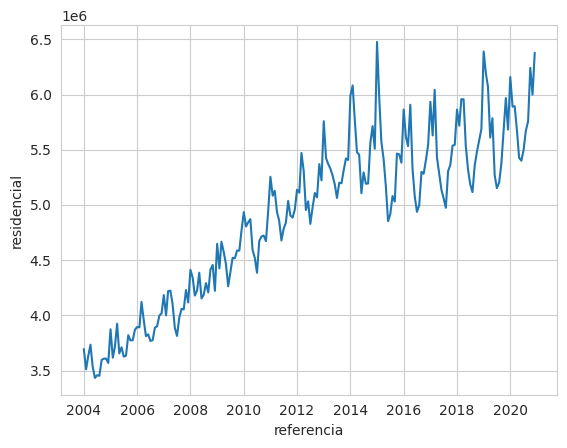

In [67]:
with sns.axes_style('whitegrid'):
    grafico = sns.lineplot(data = df_energia, x = 'referencia', y = 'residencial')

    

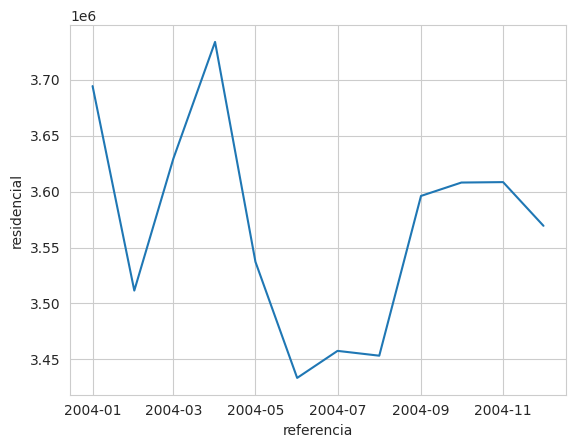

In [68]:
df_2004 = df_energia[df_energia['referencia'].dt.year == 2004]
with sns.axes_style('whitegrid'):
    grafico = sns.lineplot(data = df_2004, x = 'referencia', y = 'residencial')

# A granulidade grossa pois nao contem os dias    

# Minimo : 2004-01-01

# Maximo : 2020-12-01

In [69]:
df_temperatura = pd.read_csv('temperatura.csv', sep = ';', parse_dates = [0])

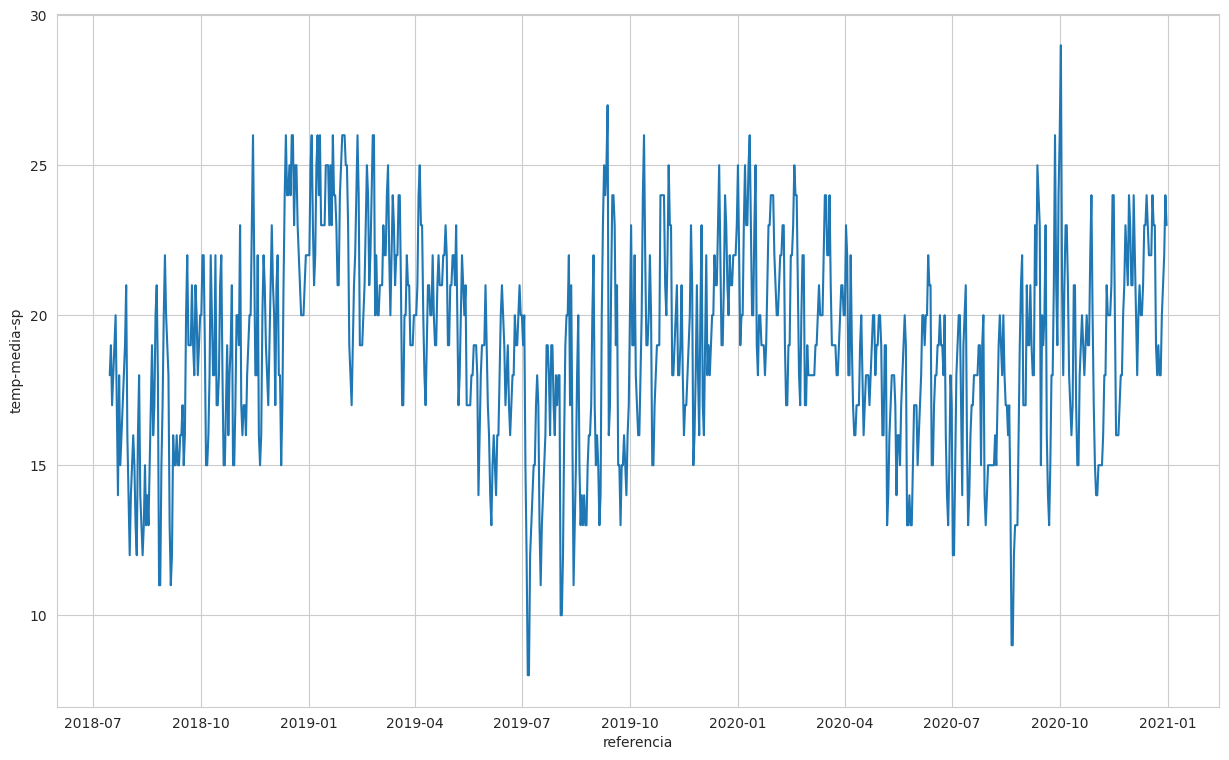

In [70]:
with sns.axes_style('whitegrid'):
    plt.figure(figsize = (15, 9))
    grafico = sns.lineplot(data = df_temperatura, x = 'referencia', y = 'temp-media-sp') 

In [71]:
df_temperatura_2018 = df_temperatura[df_temperatura['referencia'].dt.year == 2018]

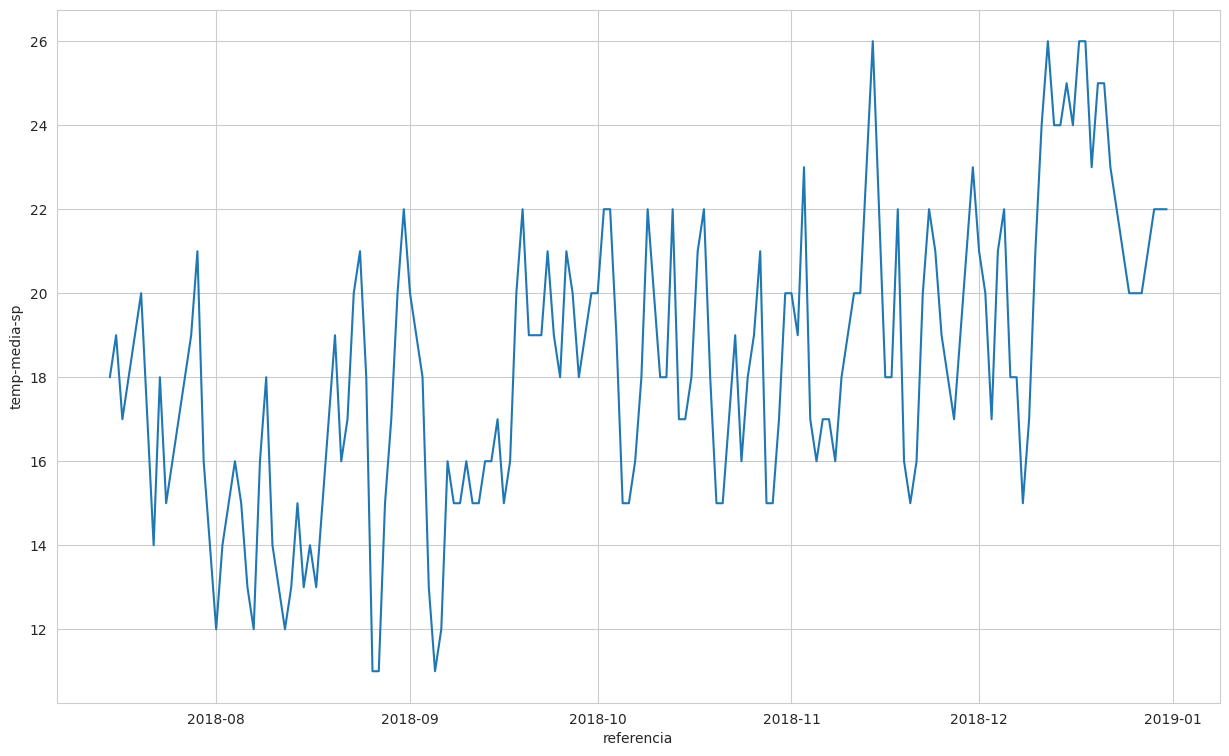

In [72]:
with sns.axes_style('whitegrid'):
    plt.figure(figsize = (15, 9))
    grafico = sns.lineplot(data = df_temperatura_2018, x = 'referencia', y = 'temp-media-sp') 
    

# Granulidade fina pois os dados entao sendo representados de mes em mes e ano em ano contando cada dia

# Minimo: 2018-07-15

# Maximo: 2020-12-31

In [73]:
df_energia = df_energia.set_index(keys = ['referencia'])

df_temperatura = df_temperatura.set_index(keys = ['referencia'])

In [75]:
df_energia_sep = df_energia['2019-01-01': '2020-12-01']

In [77]:
df_temperatura_sep = df_temperatura['2019-01-01': '2020-12-31']

In [79]:
df_temperatura_sep.dropna()

,temp-media-sp,temp-media-rj,temp-media-mg
referencia,,,
2019-01-01,22,28.0,21.0
2019-01-02,25,28.0,24.0
2019-01-03,26,31.0,24.0
2019-01-04,23,31.0,22.0
2019-01-05,21,28.0,23.0
...,...,...,...
2020-12-27,20,24.0,23.0
2020-12-28,21,25.0,23.0
2020-12-29,22,27.0,23.0


In [80]:
df_temperatura_sep['temp-media'] = df_temperatura_sep[['temp-media-sp', 'temp-media-rj', 'temp-media-mg']].mean(axis=1).round(2)

C:\Users\lucas\AppData\Local\Temp\ipykernel_21368\4130852616.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_temperatura_sep['temp-media'] = df_temperatura_sep[['temp-media-sp', 'temp-media-rj', 'temp-media-mg']].mean(axis=1).round(2)


In [81]:
df_temperatura_sep = df_temperatura_sep.resample(rule = '1ME').mean()

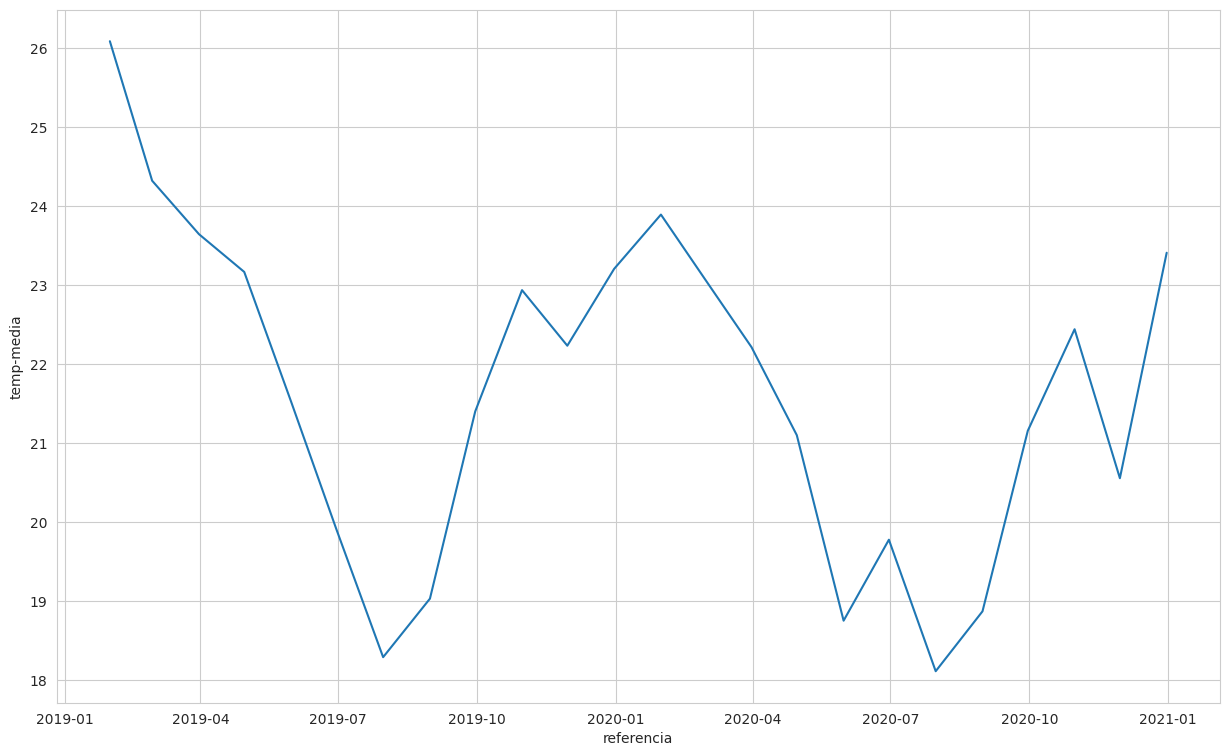

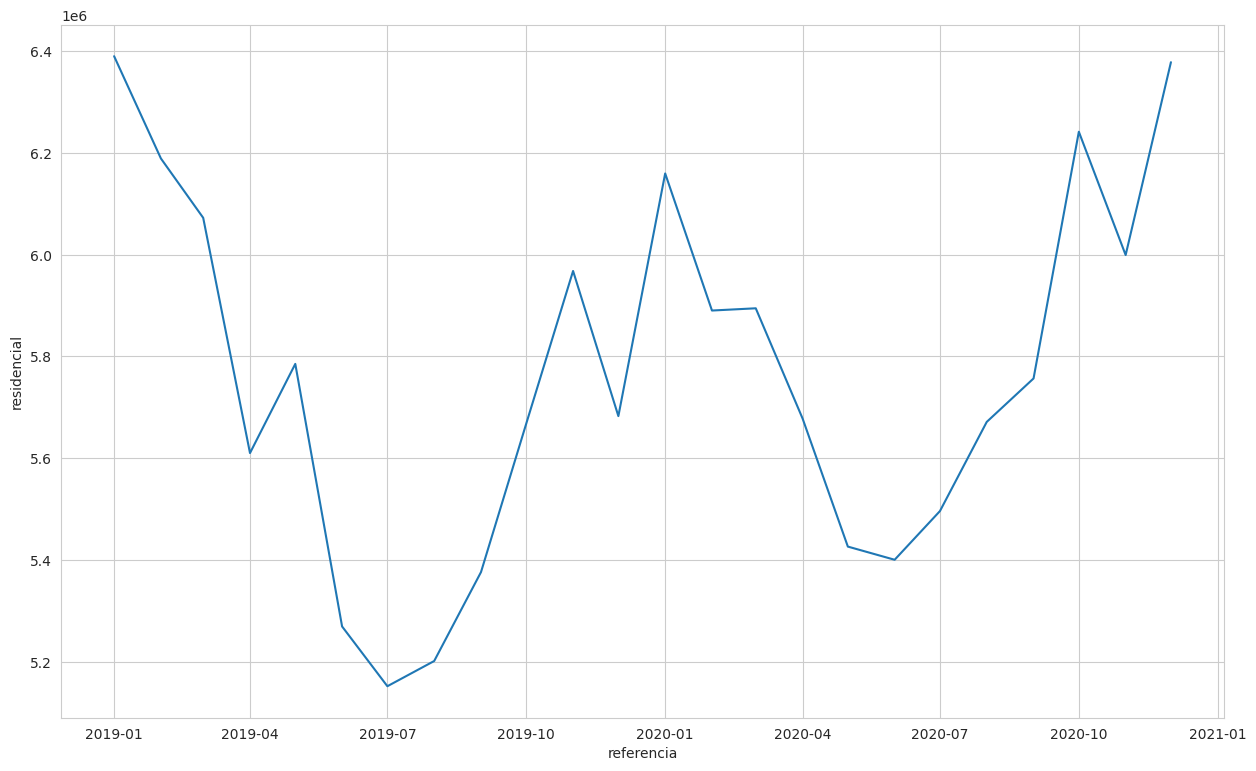

In [83]:
with sns.axes_style('whitegrid'):
    plt.figure(figsize=(15,9))
    grafico = sns.lineplot(data = df_temperatura_sep['temp-media'])

with sns.axes_style('whitegrid'):
    plt.figure(figsize = (15,9))
    grafico = sns.lineplot(data = df_energia_sep['residencial'])    

In [84]:
correlacao_resedencia = np.corrcoef(df_energia_sep['residencial'],df_temperatura_sep['temp-media'])
correlacao_resedencia

array([[1.        , 0.78565216],
       [0.78565216, 1.        ]])

# Sim a temperatura e um bom atributo 

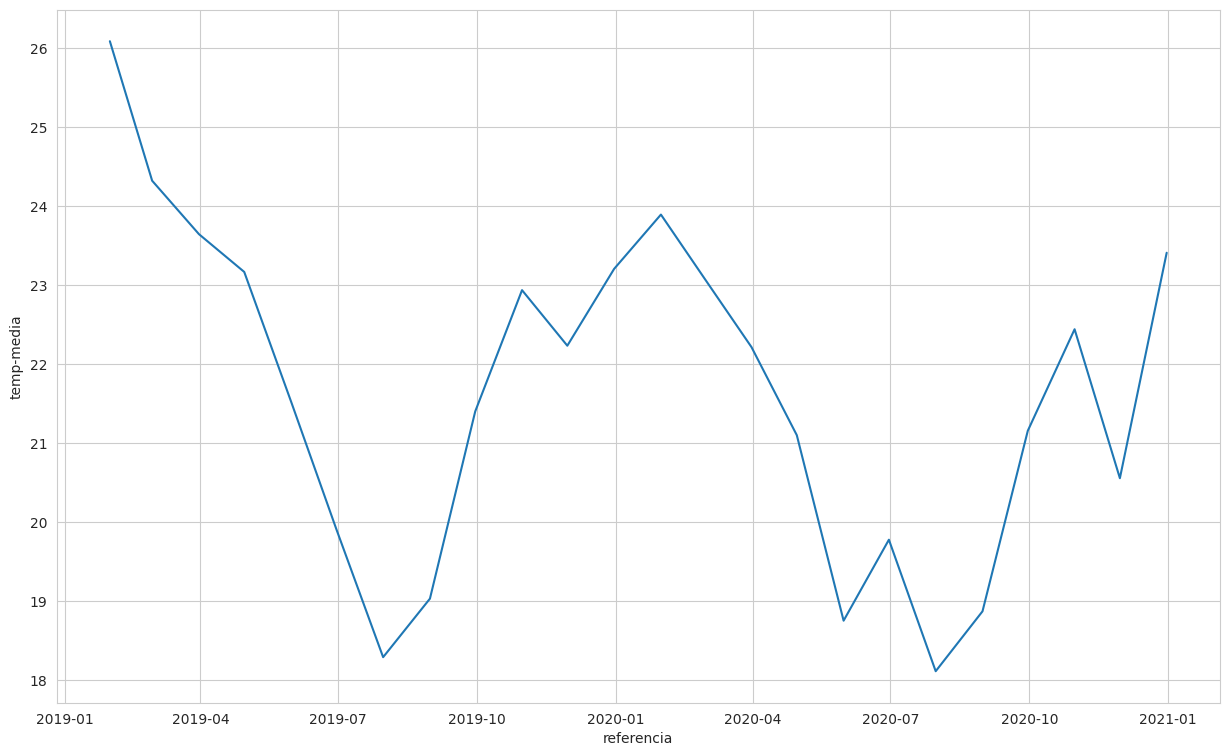

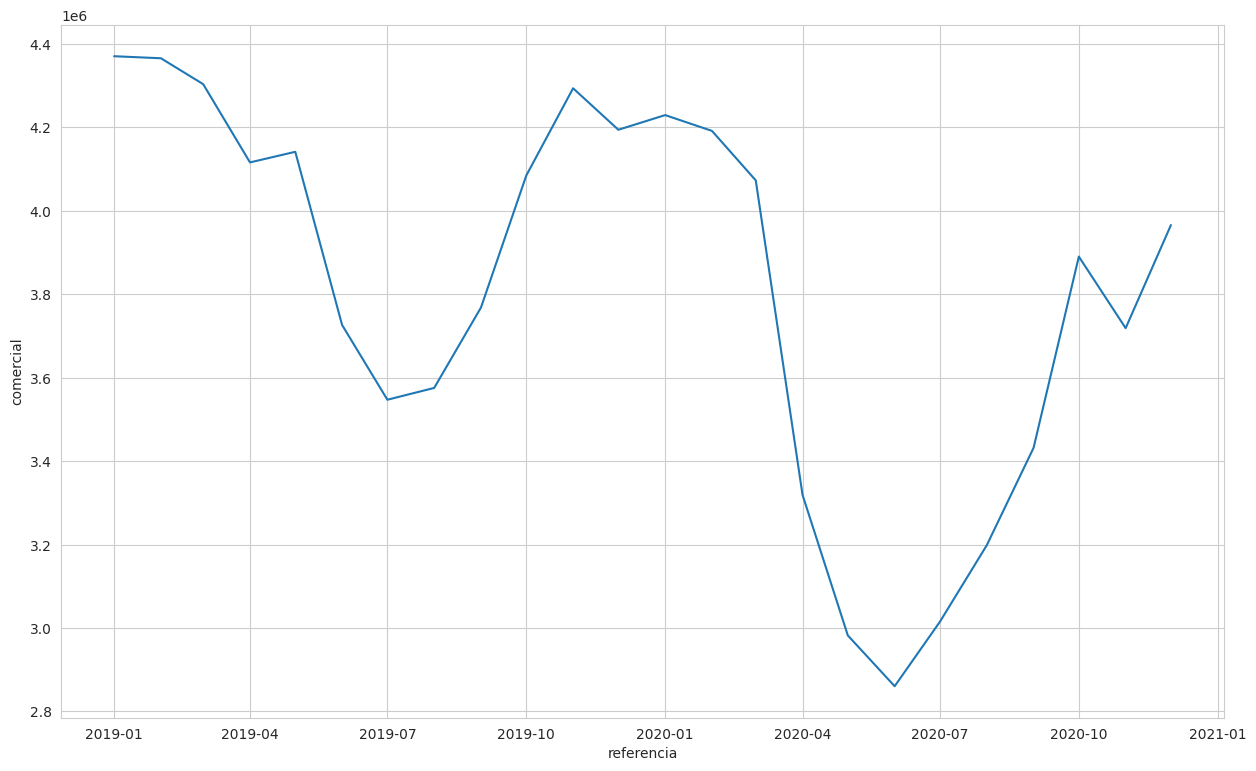

In [85]:
with sns.axes_style('whitegrid'):
    plt.figure(figsize=(15,9))
    grafico = sns.lineplot(data = df_temperatura_sep['temp-media'])

with sns.axes_style('whitegrid'):
    plt.figure(figsize = (15,9))
    grafico = sns.lineplot(data = df_energia_sep['comercial'])  

In [86]:
correlacao_comercial = np.corrcoef(df_energia_sep['comercial'],df_temperatura_sep['temp-media'])
correlacao_comercial

array([[1.        , 0.84971075],
       [0.84971075, 1.        ]])

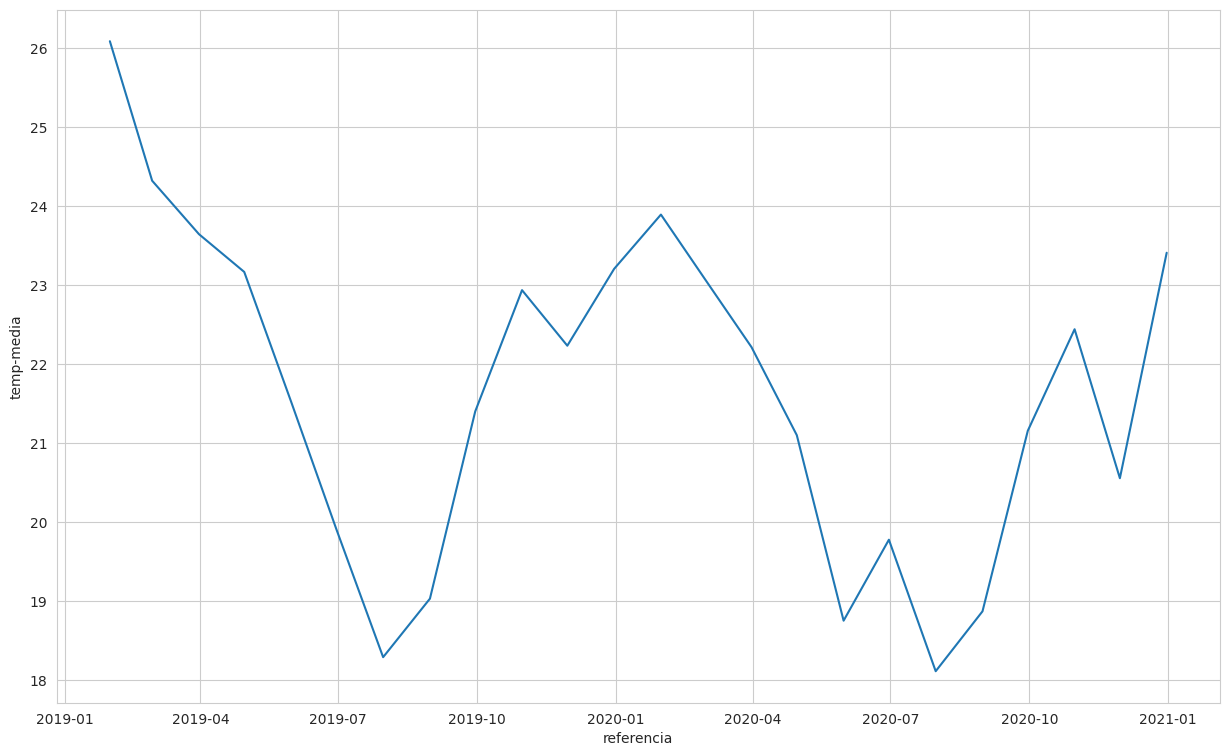

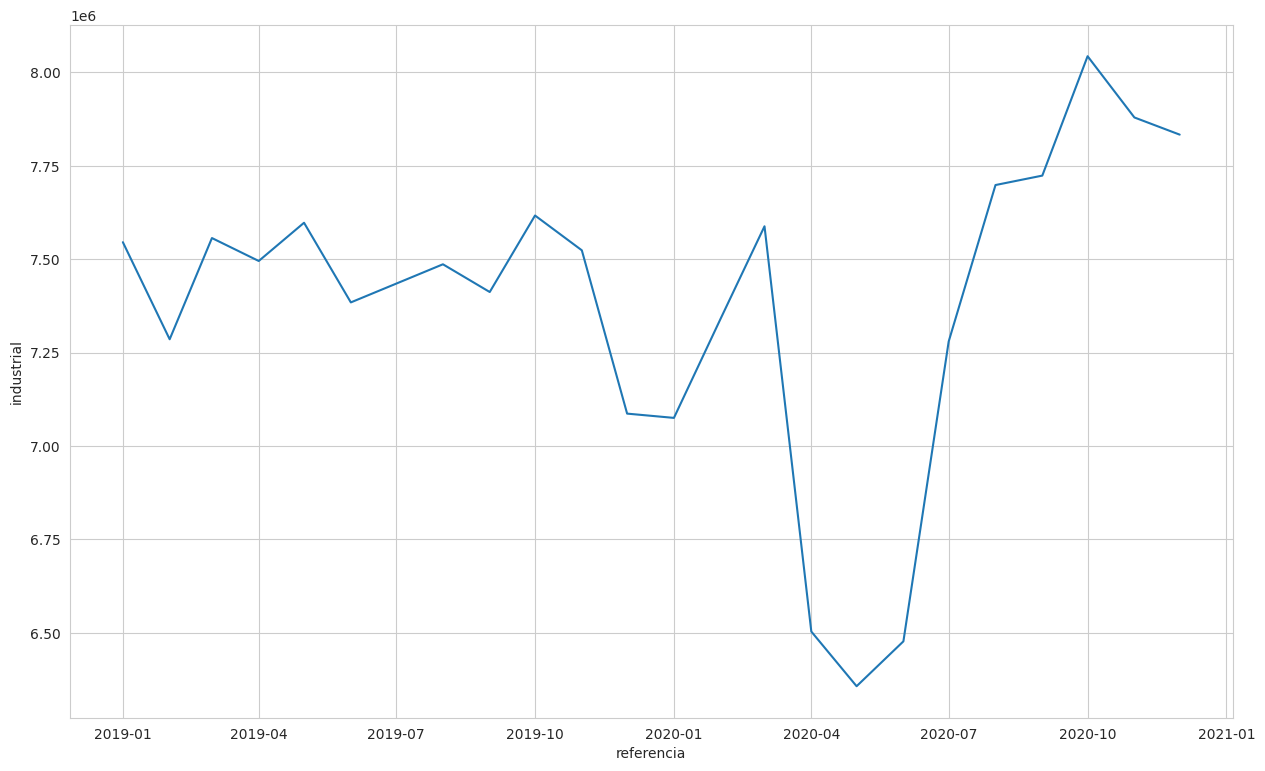

In [87]:
with sns.axes_style('whitegrid'):
    plt.figure(figsize=(15,9))
    grafico = sns.lineplot(data = df_temperatura_sep['temp-media'])

with sns.axes_style('whitegrid'):
    plt.figure(figsize = (15,9))
    grafico = sns.lineplot(data = df_energia_sep['industrial'])  

In [88]:
correlacao_industrial = np.corrcoef(df_energia_sep['industrial'],df_temperatura_sep['temp-media'])
correlacao_industrial

array([[1.        , 0.24104642],
       [0.24104642, 1.        ]])